# 실습 1: 이미지 분류

## 1) Ultralytics 버전

In [ ]:
# 설치 uv pip install git+https://github.com/ultralytics/CLIP.git (FastSAM 실습하면 서 설치됨)

### 모델 불러오기

In [1]:
import clip 
import torch 
from PIL import Image 

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

### 이미지/텍스트 준비하기

In [2]:
image_path = "./images/dog.jpeg"
classes = ["a person", "a car", "a dog", "a cat"]

img = Image.open(image_path)

### 모델에 넣을 준비

In [3]:
image = preprocess(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

### 유사도 계산하기

In [9]:
with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image)
    print("="*20)
    print(_)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    print("="*20)
    print(probs)

tensor([[21.5625, 20.6719, 26.0938, 20.0469]], device='cuda:0',
       dtype=torch.float16)
tensor([[21.5625],
        [20.6719],
        [26.0938],
        [20.0469]], device='cuda:0', dtype=torch.float16)
[0.01058  0.00434  0.983    0.002325]


### 결과

In [10]:
for label, prob in zip(classes, probs):
    print(f"{label}: {prob:.4f}")

a person: 0.0106
a car: 0.0043
a dog: 0.9829
a cat: 0.0023


In [13]:
prob_test = torch.tensor([0.01058,  0.00434,  0.983,    0.002325])
classes = ["a person", "a car", "a dog", "a cat"]

# "a dog"
print(prob_test.argmax())
print(classes[prob_test.argmax()])

tensor(2)
a dog


#### unsqueeze란?

In [7]:
import torch 

x1 = torch.tensor([1.0, 2.0, 3.0])
print(x1)
print(x1.shape)

x2 = x1.unsqueeze(0)
print(x2)
print(x2.shape)

tensor([1., 2., 3.])
torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


## 2) HuggingFace 버전

In [14]:
# https://huggingface.co/openai/clip-vit-base-patch32

### 모델 불러오기

In [ ]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

### 이미지/텍스트 준비하기

In [36]:
from PIL import Image

image_path = "./images/sit.jpg"
classes = [
    "a person standing",
    "a person sitting",
    "a person running"
]

img = Image.open(image_path)

### 모델에 넣을 준비

In [37]:
inputs = processor(
    text=classes, 
    images=img, 
    return_tensors="pt", 
    padding=True
)

### 유사도 계산하기

In [38]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities

In [39]:
print(probs)

tensor([[0.4514, 0.5233, 0.0253]], grad_fn=<SoftmaxBackward0>)


In [40]:
print(probs[0])

tensor([0.4514, 0.5233, 0.0253], grad_fn=<SelectBackward0>)


In [41]:
print(classes)

['a person standing', 'a person sitting', 'a person running']


In [42]:
for label, prob in zip(classes, probs[0]):
    print(f"{label}: {prob:.4f}")

a person standing: 0.4514
a person sitting: 0.5233
a person running: 0.0253


In [43]:
max_idx = probs[0].argmax()
print(max_idx)
result = classes[max_idx]
print(result)

tensor(1)
a person sitting


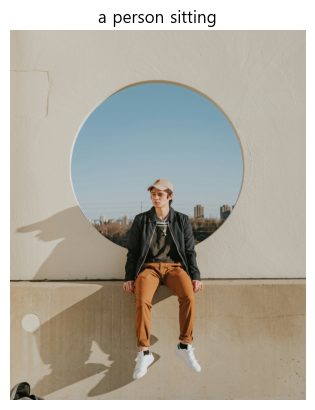

In [44]:
import matplotlib.pyplot as plt 

plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()

# 실습 2: 이미지 검색

## 모델 불러오기

In [2]:
import torch 

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

## 검색 대상 폴더 불러오기

In [4]:
image_folder = "./images/clothes"

# 파이썬으로 폴더 안에 있는 파일들 경로 불러오기
import os 

files = []

allow_extensions = ["jpg", "jpeg", "png"]
for file in os.listdir(image_folder):
    if file.split(".")[-1] in allow_extensions:
        files.append(os.path.join(image_folder, file))

print(files)

['./images/clothes\\image5.jpg', './images/clothes\\image3.jpg', './images/clothes\\image2.jpg', './images/clothes\\image1.jpg', './images/clothes\\image4.jpg']


## 폴더 이미지 벡터화하기

In [6]:
from PIL import Image

image_features = []
for file in files:
    image = Image.open(file)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        feature = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        feature = model.visual_projection(feature)
        feature /= feature.norm(dim=-1, keepdim=True)

    image_features.append(feature.cpu())

image_features = torch.cat(image_features, dim=0)

In [20]:
# cat 예시 
feat1 = torch.tensor([[1.0, 2.0, 3.0]])
feat2 = torch.tensor([[4.0, 5.0, 6.0]])

features = [feat1, feat2]
print(features)

features_cat = torch.cat(features, dim=0)
print(features_cat)

[tensor([[1., 2., 3.]]), tensor([[4., 5., 6.]])]
tensor([[1., 2., 3.],
        [4., 5., 6.]])


## 검색하기

In [24]:
# 검색 설정
query = "a black shirt"
top_k = 3

In [25]:
# 텍스트 벡터화 
inputs = processor(
    text=[query], return_tensors="pt"
).to(device)

with torch.no_grad():
    text_feature = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    ).pooler_output
    text_feature = model.text_projection(text_feature)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

In [26]:
# 유사도 계산
similarity = (image_features @ text_feature.cpu().T).squeeze(1) # 코사인 유사도 공식
top_indices = similarity.argsort(descending=True)[:top_k] # 정렬 순서를 위치로 반환

print(similarity)
print(files)
print(top_indices)

tensor([0.2430, 0.2827, 0.2327, 0.2236, 0.2399])
['./images/clothes\\image5.jpg', './images/clothes\\image3.jpg', './images/clothes\\image2.jpg', './images/clothes\\image1.jpg', './images/clothes\\image4.jpg']
tensor([1, 0, 4])


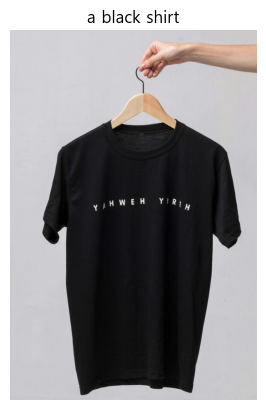

In [29]:
import matplotlib.pyplot as plt 

img = Image.open(files[1])

plt.imshow(img)
plt.title(query)
plt.axis("off")
plt.show()

# 실습 3: 모델 융합(YOLO + CLIP)

In [ ]:
# 나는 이미지에서 사람이 앉아있는지 아닌지를 분류하고 싶습니다.
# sit.jpg 준비
# YOLO로 person 찾기
# CLIP 실습 1을 활용해서 person 분류하기

## 모델 불러오기

In [137]:
from ultralytics import YOLO

yolo_model = YOLO("./models/yolo26n.pt")

In [138]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [139]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
yolo_model = yolo_model.to(device)
clip_model = clip_model.to(device)

## 이미지/텍스트 준비하기

In [140]:
image_path = "./images/sit.jpg"
classes = ["a person standing", "a person sitting"]

## YOLO로 객체 감지하기

In [141]:
yolo_result = yolo_model(source=image_path)[0]
yolo_result


image 1/1 c:\potenup3\pj03_deep_learning\images\sit.jpg: 640x512 1 person, 19.1ms
Speed: 4.9ms preprocess, 19.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [142]:
yolo_result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8276], device='cuda:0')
data: tensor([[1.3058e+03, 1.6903e+03, 2.1976e+03, 3.9156e+03, 8.2755e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (4220, 3376)
shape: torch.Size([1, 6])
xywh: tensor([[1751.7485, 2802.9641,  891.8029, 2225.2871]], device='cuda:0')
xywhn: tensor([[0.5189, 0.6642, 0.2642, 0.5273]], device='cuda:0')
xyxy: tensor([[1305.8470, 1690.3206, 2197.6499, 3915.6077]], device='cuda:0')
xyxyn: tensor([[0.3868, 0.4005, 0.6510, 0.9279]], device='cuda:0')

In [143]:
names = yolo_result.names
boxes = yolo_result.boxes

person_list = []
for data in boxes.data:
    x1, y1, x2, y2, conf, idx = data.to("cpu")
    if names[int(idx)] == "person":
        person_list.append(data.to("cpu"))

In [144]:
print(person_list)

[tensor([1.3058e+03, 1.6903e+03, 2.1976e+03, 3.9156e+03, 8.2755e-01, 0.0000e+00])]


## 객체 감지한 결과에서 CLIP으로 분류하기

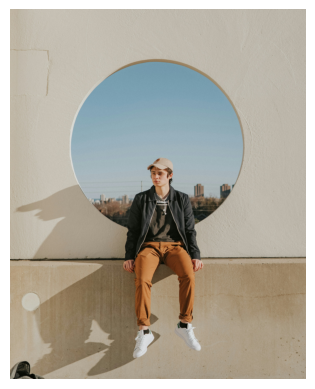

In [145]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.show()

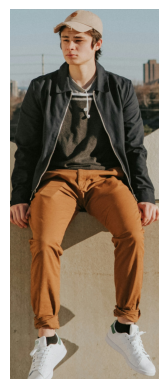

In [146]:
import matplotlib.pyplot as plt

x1, y1, x2, y2, conf, idx = person_list[0]
crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

plt.imshow(crop_image)
plt.axis("off")
plt.show()

In [147]:
from PIL import Image

image = Image.open(image_path)

for data in person_list:
    x1, y1, x2, y2, conf, idx = data
    crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

    inputs = processor(
        text=classes, images=crop_image, return_tensors="pt", padding=True
    ).to(device)

    # print(inputs)

    with torch.no_grad():
        output = clip_model(**inputs)
        logits_per_image = output.logits_per_image
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    best = classes[probs.argmax()]
    print(f"{best} {probs.max(): .4f}")

a person sitting  0.5386


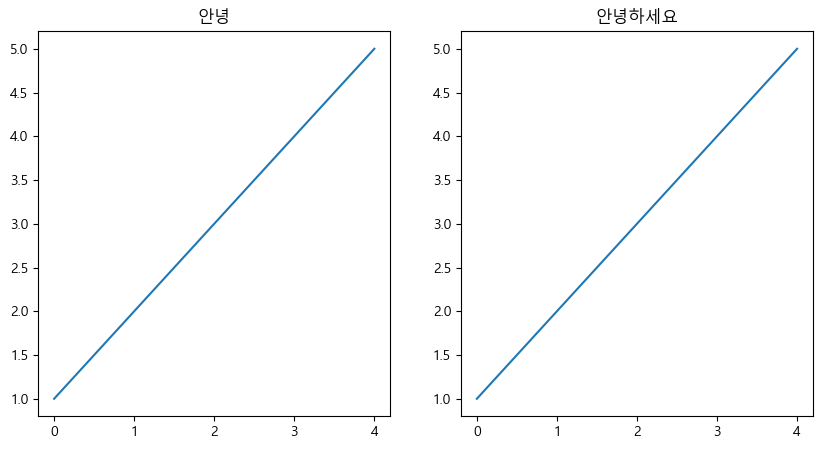

In [148]:
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"

font_manager.fontManager.addfont(font_path)
rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot([1, 2, 3, 4, 5])
axes[0].set_title("안녕")

axes[1].plot([1, 2, 3, 4, 5])
axes[1].set_title("안녕하세요")

plt.show()